# Compile metrics across all runs
 
This notebook loads MAGICC output for all model-scenario combinations and extracts
temperature metrics at key points:
- At net-zero CO2
- At 2100
 
 For the following temperature components:
 - ALL (total warming)
 - CO2 [NZCO2] (CO2 warming at net-zero)
 - CO2 [Negative] (warming from negative CO2 emissions)
 - Non-CO2 GHG
 - Residual

In [1]:
import os
from pathlib import Path

import dotenv
import numpy as np
import pandas as pd
import pyam
from tqdm import tqdm

from utils import (
    get_value_at_netzero,
    get_value_at_year
)
from metrics import (
    load_runs_manifest,
    load_scenario_data,
    extract_metrics,
    DEFAULT_VARIABLES,
    DEFAULT_VAR_SHORT_NAMES,
)

%load_ext autoreload
%autoreload 2

# Load environment variables
dotenv.load_dotenv()

# Set up output folder
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

# Configuration
OUTPUT_DIR = OUTPUT_FOLDER / "individual_runs"
NETZERO_META_FILE = OUTPUT_FOLDER / "102_netzero_timings.csv"
MANIFEST_FILE = OUTPUT_FOLDER / "individual_runs/manifests/2026-05-13_11-42_manifest.csv"

/Users/ganti/Documents/code/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/jwt/api_jwt.py:147: InsecureKeyLengthWarning: The HMAC key is 20 bytes long, which is below the minimum recommended length of 32 bytes for SHA256. See RFC 7518 Section 3.2.
  return self._jws.encode(
/Users/ganti/Documents/code/ar7_netzero_assessment/.venv/lib/python3.13/site-packages/scmdata/database/_database.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  import tqdm.autonotebook as tqdman
[WARNING] 11:54:46 - pint.util: Redefining 'C' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
[WARNING] 11:54:46 - pint.util: Redefining 'N' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
[WARNING] 11:54:46 - pint.util: Redefining 'NOX' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
[WARNING] 11:54:46 - pint.util: Redefining 'gNOX' (<class 'pint.delegates.txt_defparser.pla

In [2]:
# Load and pivot runs manifest
runs_pivoted = load_runs_manifest(MANIFEST_FILE)

print(f"Found {len(runs_pivoted)} unique model-scenario combinations")
runs_pivoted

Found 4 unique model-scenario combinations


,,ensemble_members_ALL,ensemble_members_CO2,ensemble_members_GHG,n_processes_ALL,n_processes_CO2,n_processes_GHG,output_filename_ALL,output_filename_CO2,output_filename_GHG,output_filename_NZCO2
model,scenario,,,,,,,,,,
COFFEE 1.1,ENGAGE-NPi2020-400f-lowBECCS,600,600,600,10,2,2,COFFEE__1.1_ENGAGE-NPi2020-400f-lowBECCS_ALL.csv,COFFEE__1.1_ENGAGE-NPi2020-400f-lowBECCS_CO2.csv,COFFEE__1.1_ENGAGE-NPi2020-400f-lowBECCS_GHG.csv,COFFEE__1.1_ENGAGE-NPi2020-400f-lowBECCS_NZCO2...
MESSAGEix-GLOBIOM 1.0,LowEnergyDemand (1.3/IPCC-AR6),600,600,600,2,2,2,MESSAGEix-GLOBIOM__1.0_LowEnergyDemand__(1.3__...,MESSAGEix-GLOBIOM__1.0_LowEnergyDemand__(1.3__...,MESSAGEix-GLOBIOM__1.0_LowEnergyDemand__(1.3__...,MESSAGEix-GLOBIOM__1.0_LowEnergyDemand__(1.3__...
REMIND-MAgPIE 2.1-4.2,SusDev-SDP-1000,600,600,600,10,2,2,REMIND-MAgPIE__2.1-4.2_SusDev-SDP-1000_ALL.csv,REMIND-MAgPIE__2.1-4.2_SusDev-SDP-1000_CO2.csv,REMIND-MAgPIE__2.1-4.2_SusDev-SDP-1000_GHG.csv,REMIND-MAgPIE__2.1-4.2_SusDev-SDP-1000_NZCO2_C...
REMIND-MAgPIE 2.1-4.3,DeepElectrification-SSP2-HighRenewables-900,600,600,600,2,2,2,REMIND-MAgPIE__2.1-4.3_DeepElectrification-SSP...,REMIND-MAgPIE__2.1-4.3_DeepElectrification-SSP...,REMIND-MAgPIE__2.1-4.3_DeepElectrification-SSP...,REMIND-MAgPIE__2.1-4.3_DeepElectrification-SSP...


In [3]:
# Use default variable configurations from metrics.py
# These can be overridden if needed
VARIABLES = DEFAULT_VARIABLES
VAR_SHORT_NAMES = DEFAULT_VAR_SHORT_NAMES

In [4]:
# Load net-zero metadata
netzero_meta = pd.read_csv(NETZERO_META_FILE)

In [5]:
# Process all scenarios and compile metrics
all_metrics = []

for model, scenario in tqdm(runs_pivoted.index, desc="Processing scenarios"):
    try:
        # Load scenario data
        df = load_scenario_data(model, scenario, runs_pivoted, OUTPUT_DIR)
        
        # Load net-zero metadata
        df.load_meta(NETZERO_META_FILE)
        
        # Extract metrics
        metrics = extract_metrics(df, VARIABLES, VAR_SHORT_NAMES)
        
        if not metrics.empty:
            all_metrics.append(metrics)
            
    except Exception as e:
        print(f"Error processing {model} / {scenario}: {e}")
        continue

# Combine all metrics into single DataFrame
metrics_df = pd.concat(all_metrics, axis=0)
print(f"\nCompiled metrics for {len(metrics_df)} runs across {len(runs_pivoted)} scenarios")

Processing scenarios:   0%|          | 0/4 [00:00<?, ?it/s][INFO] 11:54:46 - pyam.core: Reading file /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/individual_runs/COFFEE__1.1_ENGAGE-NPi2020-400f-lowBECCS_ALL.csv
[INFO] 11:54:46 - pyam.core: Reading file /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/individual_runs/COFFEE__1.1_ENGAGE-NPi2020-400f-lowBECCS_CO2.csv
[INFO] 11:54:46 - pyam.core: Reading file /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/individual_runs/COFFEE__1.1_ENGAGE-NPi2020-400f-lowBECCS_GHG.csv
[INFO] 11:54:47 - pyam.core: Reading file /Users/ganti/Documents/code/ar7_netzero_assessment/analysis/output/individual_runs/COFFEE__1.1_ENGAGE-NPi2020-400f-lowBECCS_NZCO2_CO2.csv
[WARNING] 11:54:48 - pyam.core: Ignoring meta indicators for the following scenarios:
         model       scenario
0  AIM/CGE 2.0        SSP1-19
1  AIM/CGE 2.0        SSP1-26
2  AIM/CGE 2.0        SSP1-34
3  AIM/CGE 2.0        SSP1-45
4  


Compiled metrics for 2400 runs across 4 scenarios


In [6]:
# View the compiled metrics
metrics_df.round(2)

GSAT|ALL|NZCO2  \
model                 scenario                                    run_id                   
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                0                 1.97   
                                                                  1                 3.08   
                                                                  2                 2.15   
                                                                  3                 1.66   
                                                                  4                 2.03   
...                                                                                  ...   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900 595               1.46   
                                                                  596               2.55   
                                                                  597               1.99   
                                                                  598               1.53   
                                                                  599               1.67   

                                                                          GSAT|ALL|2100  \
model                 scenario                                    run_id                  
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                0                1.82   
                                                                  1                3.15   
                                                                  2                1.98   
                                                                  3                1.43   
                                                                  4                1.92   
...                                                                                 ...   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900 595              1.33   
                                                                  596              2.68   
                                                                  597              2.04   
                                                                  598              1.47   
                                                                  599              1.67   

                                                                          GSAT|CO2_NZCO2|NZCO2  \
model                 scenario                                    run_id                         
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                0                       1.72   
                                                                  1                       3.10   
                                                                  2                       1.81   
                                                                  3                       1.35   
                                                                  4                       1.69   
...                                                                                        ...   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900 595                     1.28   
                                                                  596                     2.38   
                                                                  597                     1.69   
                                                                  598                     1.32   
                                                                  599                     1.47   

                                                                          GSAT|CO2_NZCO2|2100  \
model                 scenario                                    run_id                        
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                0                      1.68   
                                                                  1                      3.31   
                              

In [7]:
metrics_df.groupby(['model', 'scenario'])['GSAT|ALL|max'].median()

model                  scenario                                   
COFFEE 1.1             ENGAGE-NPi2020-400f-lowBECCS                   1.862566
MESSAGEix-GLOBIOM 1.0  LowEnergyDemand (1.3/IPCC-AR6)                 1.673037
REMIND-MAgPIE 2.1-4.2  SusDev-SDP-1000                                1.598726
REMIND-MAgPIE 2.1-4.3  DeepElectrification-SSP2-HighRenewables-900    1.617638
Name: GSAT|ALL|max, dtype: float64

In [8]:
# Calculate delta (2100 - NZCO2) for each component
components = ["ALL", "CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]

for comp in components:
    metrics_df[f"GSAT|{comp}|delta"] = (
        metrics_df[f"GSAT|{comp}|2100"] - metrics_df[f"GSAT|{comp}|NZCO2"]
    )

# Display delta columns
delta_cols = [col for col in metrics_df.columns if "|delta" in col]
print("Delta (2100 - NZCO2) for each component:")
metrics_df[delta_cols].round(3)

Delta (2100 - NZCO2) for each component:


GSAT|ALL|delta  \
model                 scenario                                    run_id                   
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                0               -0.151   
                                                                  1                0.066   
                                                                  2               -0.173   
                                                                  3               -0.221   
                                                                  4               -0.115   
...                                                                                  ...   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900 595             -0.128   
                                                                  596              0.134   
                                                                  597              0.045   
                                                                  598             -0.054   
                                                                  599              0.004   

                                                                          GSAT|CO2_NZCO2|delta  \
model                 scenario                                    run_id                         
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                0                     -0.035   
                                                                  1                      0.205   
                                                                  2                     -0.032   
                                                                  3                     -0.063   
                                                                  4                     -0.039   
...                                                                                        ...   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900 595                   -0.110   
                                                                  596                    0.091   
                                                                  597                    0.041   
                                                                  598                   -0.026   
                                                                  599                    0.008   

                                                                          GSAT|CO2_Negative|delta  \
model                 scenario                                    run_id                            
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                0                        -0.171   
                                                                  1                        -0.245   
                                                                  2                        -0.177   
                                                                  3                        -0.140   
                                                                  4                        -0.162   
...                                                                                           ...   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900 595                      -0.010   
                                                                  596                      -0.015   
                                                                  597                      -0.010   
                                                                  598                      -0.009   
                                                                  599                      -0.010   

                                                                          GSAT|NonCO2_GHG|delta  \
model                 scenario                                    run_id                          
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                0                      -

In [9]:
import matplotlib.pyplot as plt

# Drop validation columns for plotting (only those that exist)
validation_cols = ["sum_components|NZCO2", "diff|NZCO2", "sum_components|2100", "diff|2100", "prop_sum"]
cols_to_drop = [c for c in validation_cols if c in metrics_df.columns]
metrics_df_clean = metrics_df.drop(columns=cols_to_drop)

# Calculate statistics by scenario (across run_id)
stats = metrics_df_clean.groupby(["model", "scenario"]).agg(
    ["median", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
)

# Rename the lambda functions to clearer names
stats.columns = stats.columns.set_levels(["median", "p25", "p75"], level=1)

# Create scenario labels for plotting
scenario_labels = [f"{m}\n{s[:30]}" for m, s in stats.index]

stats.round(2)

GSAT|ALL|NZCO2  \
                                                                          median   
model                 scenario                                                     
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                          1.85   
MESSAGEix-GLOBIOM 1.0 LowEnergyDemand (1.3/IPCC-AR6)                        1.63   
REMIND-MAgPIE 2.1-4.2 SusDev-SDP-1000                                       1.44   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900           1.58   

                                                                               \
                                                                    p25   p75   
model                 scenario                                                  
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                 1.64  2.08   
MESSAGEix-GLOBIOM 1.0 LowEnergyDemand (1.3/IPCC-AR6)               1.44  1.86   
REMIND-MAgPIE 2.1-4.2 SusDev-SDP-1000                              1.26  1.65   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900  1.39  1.79   

                                                                  GSAT|ALL|2100  \
                                                                         median   
model                 scenario                                                    
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                         1.62   
MESSAGEix-GLOBIOM 1.0 LowEnergyDemand (1.3/IPCC-AR6)                       1.42   
REMIND-MAgPIE 2.1-4.2 SusDev-SDP-1000                                      1.30   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900          1.50   

                                                                               \
                                                                    p25   p75   
model                 scenario                                                  
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                 1.39  1.89   
MESSAGEix-GLOBIOM 1.0 LowEnergyDemand (1.3/IPCC-AR6)               1.19  1.67   
REMIND-MAgPIE 2.1-4.2 SusDev-SDP-1000                              1.11  1.51   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900  1.30  1.72   

                                                                  GSAT|CO2_NZCO2|NZCO2  \
                                                                                median   
model                 scenario                                                           
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                                1.52   
MESSAGEix-GLOBIOM 1.0 LowEnergyDemand (1.3/IPCC-AR6)                              1.33   
REMIND-MAgPIE 2.1-4.2 SusDev-SDP-1000                                             1.42   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900                 1.34   

                                                                               \
                                                                    p25   p75   
model                 scenario                                                  
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                 1.30  1.75   
MESSAGEix-GLOBIOM 1.0 LowEnergyDemand (1.3/IPCC-AR6)               1.15  1.54   
REMIND-MAgPIE 2.1-4.2 SusDev-SDP-1000                              1.23  1.65   
REMIND-MAgPIE 2.1-4.3 DeepElectrification-SSP2-HighRenewables-900  1.16  1.55   

                                                                  GSAT|CO2_NZCO2|2100  \
                                                                               median   
model                 scenario                                                          
COFFEE 1.1            ENGAGE-NPi2020-400f-lowBECCS                               1.43   
MESSAGEix-GLOBIOM 1.0 LowEnergyDemand (1.3/IPCC-AR6)                             1.26   
REMIND-MAgPIE 2.1-4.2 SusDev-SDP-1000                                            1.37   
REMIND-MAgPIE 2.1-4.3 Deep

In [10]:
stats.columns

MultiIndex([(         'GSAT|ALL|NZCO2', 'median'),
            (         'GSAT|ALL|NZCO2',    'p25'),
            (         'GSAT|ALL|NZCO2',    'p75'),
            (          'GSAT|ALL|2100', 'median'),
            (          'GSAT|ALL|2100',    'p25'),
            (          'GSAT|ALL|2100',    'p75'),
            (   'GSAT|CO2_NZCO2|NZCO2', 'median'),
            (   'GSAT|CO2_NZCO2|NZCO2',    'p25'),
            (   'GSAT|CO2_NZCO2|NZCO2',    'p75'),
            (    'GSAT|CO2_NZCO2|2100', 'median'),
            (    'GSAT|CO2_NZCO2|2100',    'p25'),
            (    'GSAT|CO2_NZCO2|2100',    'p75'),
            ('GSAT|CO2_Negative|NZCO2', 'median'),
            ('GSAT|CO2_Negative|NZCO2',    'p25'),
            ('GSAT|CO2_Negative|NZCO2',    'p75'),
            ( 'GSAT|CO2_Negative|2100', 'median'),
            ( 'GSAT|CO2_Negative|2100',    'p25'),
            ( 'GSAT|CO2_Negative|2100',    'p75'),
            (  'GSAT|NonCO2_GHG|NZCO2', 'median'),
            (  'GSAT|NonCO2_GHG

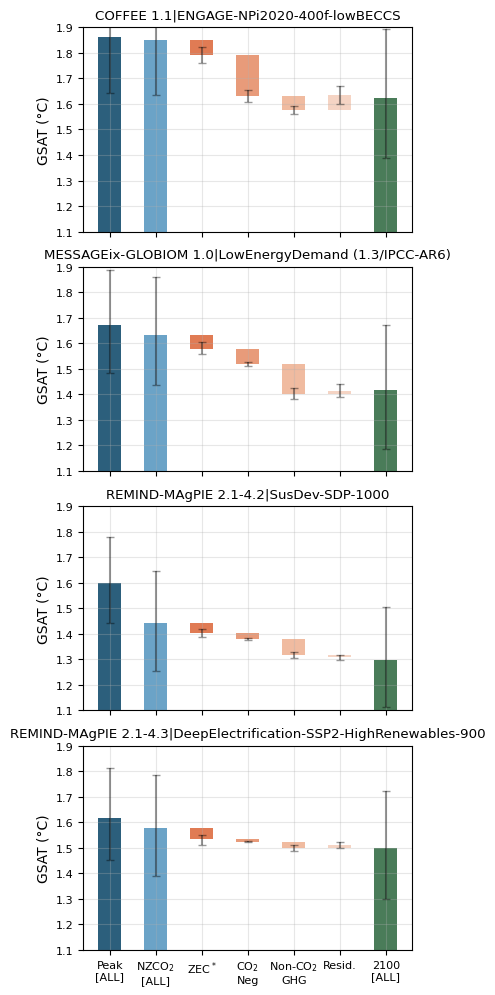

In [11]:
fig, ax = plt.subplots(4, 1, figsize=(4, 10), sharey=True, sharex=True)

# Set global font size
plt.rcParams.update({'font.size': 8})

# Color palette
color_start_dark = '#2C5F7C'      # Starting bars - darker blue
color_start_light = '#6BA3C7'     # Starting bars - lighter blue (more transparent feel)
color_delta = ['#E07B54', '#E89B7A', '#F0BBA0', '#F5D4C4']  # Delta bars - orange gradient (dark to light)
color_end = '#4A7C59'             # End bar - green

# Error bar styling
error_kw = {'ecolor': 'black', 'alpha': 0.4, 'capsize': 3, 'capthick': 1}

for i, ix in enumerate(stats.round(2).index):
    data_max = stats.loc[ix, pd.IndexSlice['GSAT|ALL|max', 'median']]
    data_max_p25 = stats.loc[ix, pd.IndexSlice['GSAT|ALL|max', 'p25']]
    data_max_p75 = stats.loc[ix, pd.IndexSlice['GSAT|ALL|max', 'p75']]
    
    data = stats.loc[ix, pd.IndexSlice['GSAT|ALL|NZCO2', 'median']]
    data_p25 = stats.loc[ix, pd.IndexSlice['GSAT|ALL|NZCO2', 'p25']]
    data_p75 = stats.loc[ix, pd.IndexSlice['GSAT|ALL|NZCO2', 'p75']]
    
    data_2100 = stats.loc[ix, pd.IndexSlice['GSAT|ALL|2100', 'median']]
    data_2100_p25 = stats.loc[ix, pd.IndexSlice['GSAT|ALL|2100', 'p25']]
    data_2100_p75 = stats.loc[ix, pd.IndexSlice['GSAT|ALL|2100', 'p75']]

    # Starting bars (blue palette with different transparency)
    ax[i].bar(x=0, height=data_max, width=0.5, color=color_start_dark,
              yerr=[[data_max - data_max_p25], [data_max_p75 - data_max]], error_kw=error_kw)
    ax[i].bar(x=1, height=data, width=0.5, color=color_start_light,
              yerr=[[data - data_p25], [data_p75 - data]], error_kw=error_kw)
    
    # End bar (green)
    ax[i].bar(x=6, height=data_2100, width=0.5, color=color_end,
              yerr=[[data_2100 - data_2100_p25], [data_2100_p75 - data_2100]], error_kw=error_kw)

    # Delta bars (orange gradient)
    bottom = data
    delta_vars = ['GSAT|CO2_NZCO2|delta', 'GSAT|CO2_Negative|delta', 'GSAT|NonCO2_GHG|delta', 'GSAT|Residual|delta']
    for j, v in enumerate(delta_vars):
        d = stats.loc[ix, pd.IndexSlice[v, 'median']]
        d_p25 = stats.loc[ix, pd.IndexSlice[v, 'p25']]
        d_p75 = stats.loc[ix, pd.IndexSlice[v, 'p75']]
        ax[i].bar(x=j+2, height=d, bottom=bottom, width=0.5, color=color_delta[j],
                  yerr=[[d - d_p25], [d_p75 - d]], error_kw=error_kw)
        bottom += d
    
    ax[i].set_ylim(1.1, 1.9)
    ax[i].tick_params(axis='both', labelsize=8)
    ax[i].grid(alpha=0.3)
    ax[i].set_ylabel("GSAT (°C)")
    ax[i].set_xticks(range(7))
    ax[i].set_xticklabels(
        [
            "Peak\n[ALL]",
            "NZCO$_2$\n[ALL]",
            "ZEC$^*$",
            "CO$_2$\nNeg",
            "Non-CO$_2$\nGHG",
            "Resid.",
            "2100\n[ALL]"
        ]
    )
    ax[i].set_title(f"{ix[0]}|{ix[1]}")

plt.tight_layout()